In [1]:
!pip install opencv-python
!pip install lightgbm
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 1.5 MB/s eta 0:00:0000:0100:01
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 2.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.6 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import concurrent.futures
from tqdm import tqdm  
import lightgbm as lgb
import optuna
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

/Users/k.v.gareev/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/k.v.gareev/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [10]:
base_path = "PetImages"
categories = ["Cat", "Dog"]
img_size = 32

In [11]:
def process_image(img_path, label):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, (img_size, img_size)).flatten()
        return img, label
    return None

In [12]:
image_paths = []
labels = []
for label, category in enumerate(categories):
    path = os.path.join(base_path, category)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        image_paths.append(img_path)
        labels.append(label)

In [13]:
X, y = [], []
with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(process_image, image_paths, labels), total=len(image_paths)))


100%|██████████| 24998/24998 [00:05<00:00, 4280.12it/s]


In [14]:
for res in results:
    if res:
        X.append(res[0])
        y.append(res[1])

In [15]:
X = np.array(X) / 255.0  
y = np.array(y)
X.shape

(24946, 1024)

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Простой логрег

In [18]:
clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC лог рег: {roc_auc:.4f}")

ROC-AUC лог рег: 0.5565


# Бустинг

In [20]:
# Подбираю гиперпараметры с помощью библиотеки optuna
def objective(trial):
    params = {
         'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves',2, 100),
        'n_estimators': trial.suggest_int('n_estimators',100,500),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples',15,30),
        'reg_lambda' : trial.suggest_float('reg_lambda',0.001,10, log=True),
        'reg_alpha' : trial.suggest_float('reg_alpha',0.001,10, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'random_state': 42
    }

    model = lgb.LGBMClassifier(**params, n_jobs = 1)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric="auc")

    y_pred = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, y_pred)

In [34]:
## несколько раз запускал подбор параметров, лучший результат параметров сохранил далее

# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=30)

In [27]:
study.best_params

{'learning_rate': 0.04168882950010141,
 'num_leaves': 69,
 'n_estimators': 376,
 'subsample': 0.17741657550864573,
 'colsample_bytree': 0.060699835055620766,
 'min_child_samples': 24,
 'reg_lambda': 0.003004559512349206,
 'reg_alpha': 2.524468046646264,
 'max_depth': 7}

In [28]:
bst_value = 0.6377986203098231
best_params = {'learning_rate': 0.04168882950010141,
 'num_leaves': 69,
 'n_estimators': 376,
 'subsample': 0.17741657550864573,
 'colsample_bytree': 0.060699835055620766,
 'min_child_samples': 24,
 'reg_lambda': 0.003004559512349206,
 'reg_alpha': 2.524468046646264,
 'max_depth': 7}

In [35]:
print("Best ROC-AUC val:", bst_value)
print("Best params val:", best_params)

Best ROC-AUC val: 0.6377986203098231
Best params val: {'learning_rate': 0.04168882950010141, 'num_leaves': 69, 'n_estimators': 376, 'subsample': 0.17741657550864573, 'colsample_bytree': 0.060699835055620766, 'min_child_samples': 24, 'reg_lambda': 0.003004559512349206, 'reg_alpha': 2.524468046646264, 'max_depth': 7}


In [36]:
# Обучаю финальную модель с лучшими параметрами
best_model = lgb.LGBMClassifier(**best_params)
best_model.fit(X_train, y_train)

y_pred = best_model.predict_proba(X_valid)[:, 1]
final_roc_auc = roc_auc_score(y_valid, y_pred)

print(f"Final ROC-AUC test: {final_roc_auc:.4f}")

[LightGBM] [Info] Number of positive: 8729, number of negative: 8733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255736
[LightGBM] [Info] Number of data points in the train set: 17462, number of used features: 1024
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499885 -> initscore=-0.000458
[LightGBM] [Info] Start training from score -0.000458
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [45]:
# Функция для оценки качества классификации с использованием PCA
# Гиперпараметры для бустинга здесь не подбирал, увидим далее, что даже без использования гиперпараметров бустинг с PCA показывает себя лучше

def evaluate_pca(X_train, y_train, X_test, y_test, n_components_list):
    auc_logreg = []
    auc_boosting = []
    explained_variance = []

    for n_components in n_components_list:
        pca = PCA(n_components=n_components)
        X_train_pca = pca.fit_transform(X_train)
        X_test_pca = pca.transform(X_test)

        # Логрег
        logreg = LogisticRegression(max_iter=1000)
        logreg.fit(X_train_pca, y_train)
        y_pred_test_logreg = logreg.predict_proba(X_test_pca)[:, 1]
        auc_logreg.append(roc_auc_score(y_test, y_pred_test_logreg))

        # бустинг
        boosting = lgb.LGBMClassifier()
        boosting.fit(X_train_pca, y_train)
        y_pred_test_boosting = boosting.predict_proba(X_test_pca)[:, 1]
        auc_boosting.append(roc_auc_score(y_test, y_pred_test_boosting))

        # Процент объясненной дисперсии
        explained_variance.append(np.sum(pca.explained_variance_ratio_))

    return auc_logreg, auc_boosting, explained_variance

n_components_list = [1, 5, 10, 20, 30, 40, 50, 100, 110, 120, 130, 150, 200]

auc_logreg, auc_boosting, explained_variance = evaluate_pca(X_train, y_train, X_test, y_test, n_components_list)


/Users/k.v.gareev/.local/lib/python3.9/site-packages/lightgbm/basic.py:722: UserWarning: Usage of np.ndarray subset (sliced data) is not recommended due to it will double the peak memory cost in LightGBM.
  _log_warning(


[LightGBM] [Info] Number of positive: 8729, number of negative: 8733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 17462, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499885 -> initscore=-0.000458
[LightGBM] [Info] Start training from score -0.000458
[LightGBM] [Info] Number of positive: 8729, number of negative: 8733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 17462, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499885 -> initscore=-0.000458
[LightGBM

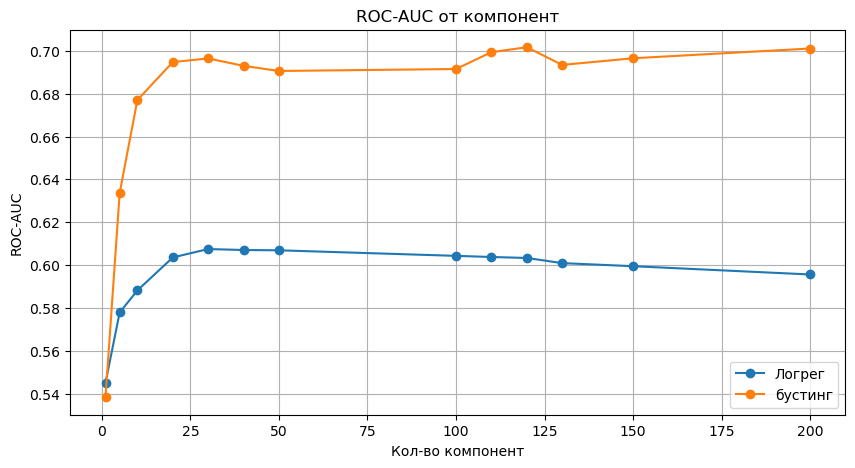

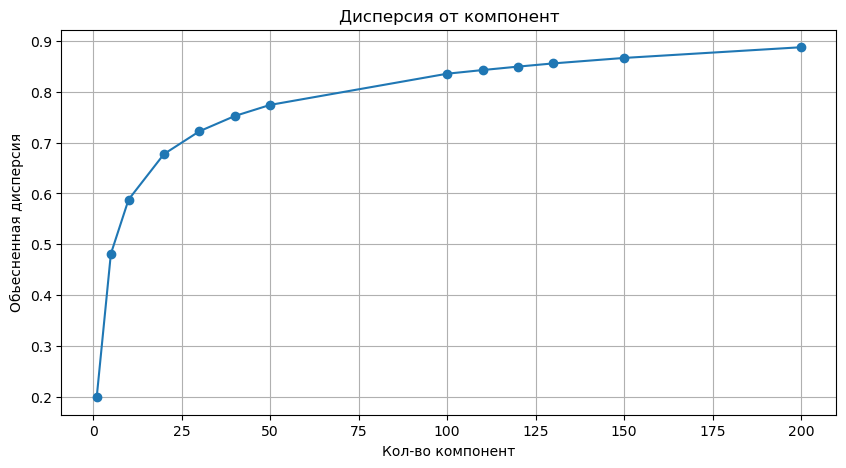

In [46]:
# ROC-AUC от компонент
plt.figure(figsize=(10, 5))
plt.plot(n_components_list, auc_logreg, label="Логрег", marker='o')
plt.plot(n_components_list, auc_boosting, label="бустинг", marker='o')
plt.xlabel("Кол-во компонент")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC от компонент")
plt.legend()
plt.grid(True)
plt.show()

# График зависимости объясненной дисперсии от числа компонент
plt.figure(figsize=(10, 5))
plt.plot(n_components_list, explained_variance, marker='o')
plt.xlabel("Кол-во компонент")
plt.ylabel("Обьесненная дисперсия")
plt.title("Дисперсия от компонент")
plt.grid(True)
plt.show()


In [51]:
explained_variance

[0.19910413230415558,
 0.48117316440139724,
 0.5879462101054622,
 0.6775253638480567,
 0.7222814946973486,
 0.7523606210710106,
 0.774219866617445,
 0.8355873109848233,
 0.8427528153265778,
 0.8495348542337389,
 0.8558716830923957,
 0.8666220753783196,
 0.8876785673896417]

n_components_list = [1, 5, 10, 20, 30, 40, 50, 100, 110, 120, 130, 150, 200] 
 
Видно, что начиная уже со 130 компонент в приципе достаточно, для обьяснения почти 90% дисперсии

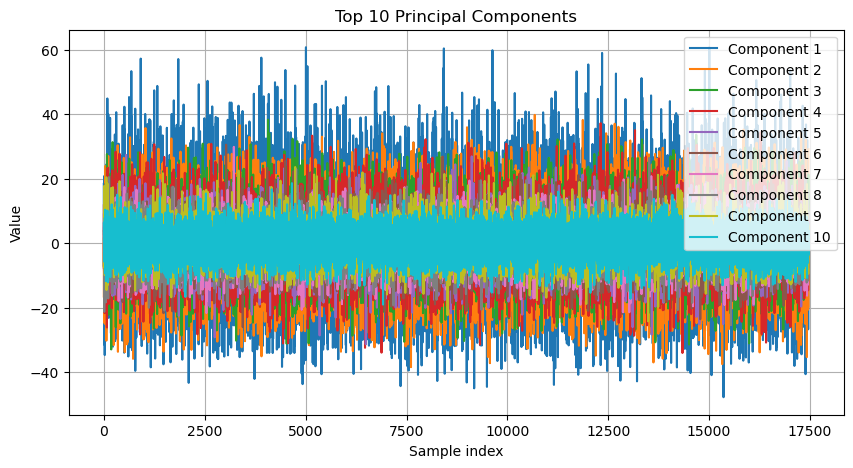

In [47]:
# 10 главных компонент
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.plot(X_train_pca[:, i], label=f"Component {i+1}")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.title("Top 10 Principal Components")
plt.legend()
plt.grid(True)
plt.show()

# Сравнение бустинга и логрега и влияние PCA на эти алгоритмы

Во первых отмечу, что даже без подбора гиперпараметров бустинг с PCA выдает качество лучше, чем без PCA, но с подбором параметров

Общая тенденция: 

PCA значительно улучшает качество градиентного бустинга при небольшом числе компонент.

Для логистической регрессии качество растет медленнее и выходит на плато раньше.

Влияние числа компонент:

Бустинг быстро набирает ROC-AUC, достигая пика при ~30-50 компонентах, после чего качество стабилизируется.

Логрег достигает своего максимума при меньшем количестве компонент (20-30), затем даже ухудшается.

Почему так?

Логистическая регрессия — линейный метод, чувствительный к потерям информации при PCA. Из-за этого уменьшение размерности не всегда помогает.

Градиентный бустинг — деревья, которым избыточная размерность (много коррелирующих признаков) может мешать. PCA убирает избыточность, что улучшает его работу.

